In [ ]:
import os, cv2, re, numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import math

In [9]:
DIR = "face_padding_roi_clahe_restore"
IMAGES_PER_ROW = 10

In [10]:
# Nhom anh theo id
groups_roi = defaultdict(list)
pattern = re.compile(r"face_id(\d+)_")

for file in sorted(os.listdir(DIR)):
    match = pattern.search(file)
    if match:
        tid = int(match.group(1))
        groups_roi[tid].append(file)

Tìm thấy 15 ID trong thư mục face_padding_roi_clahe_restore


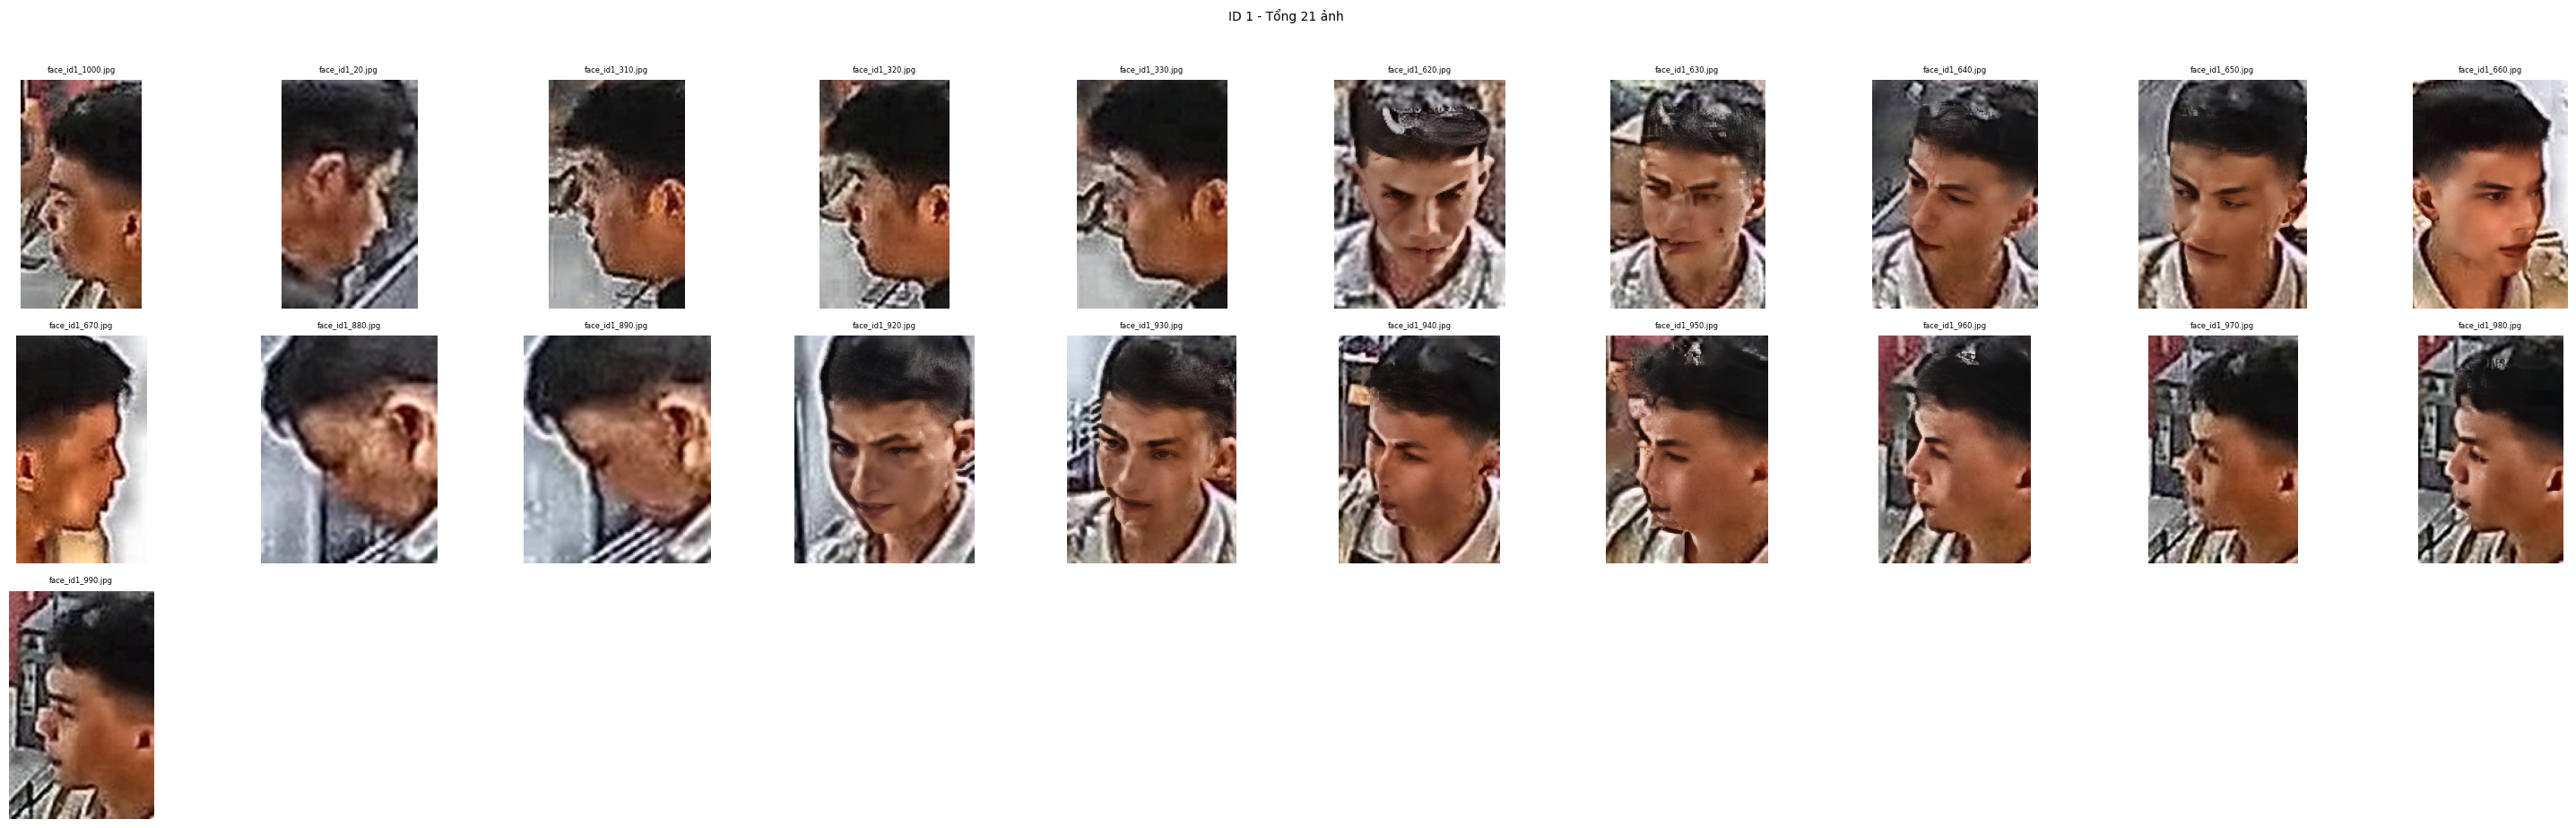

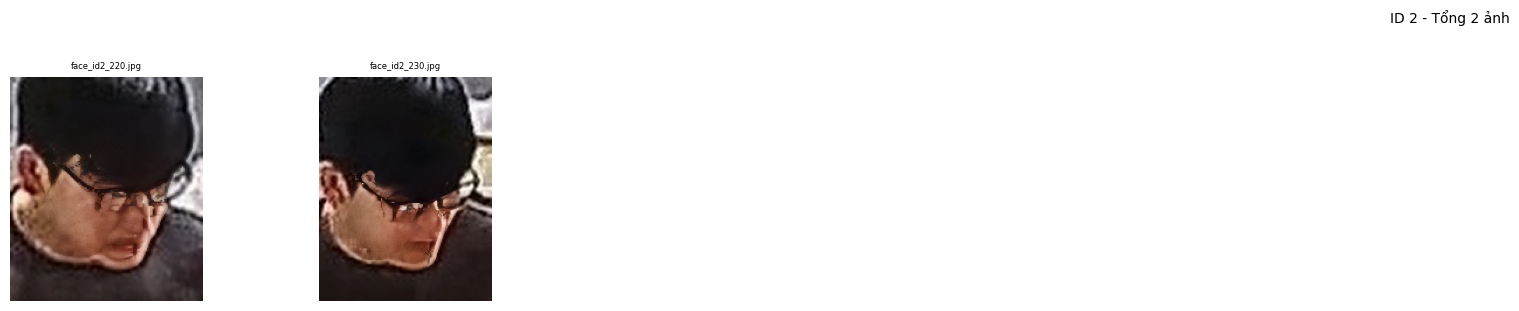

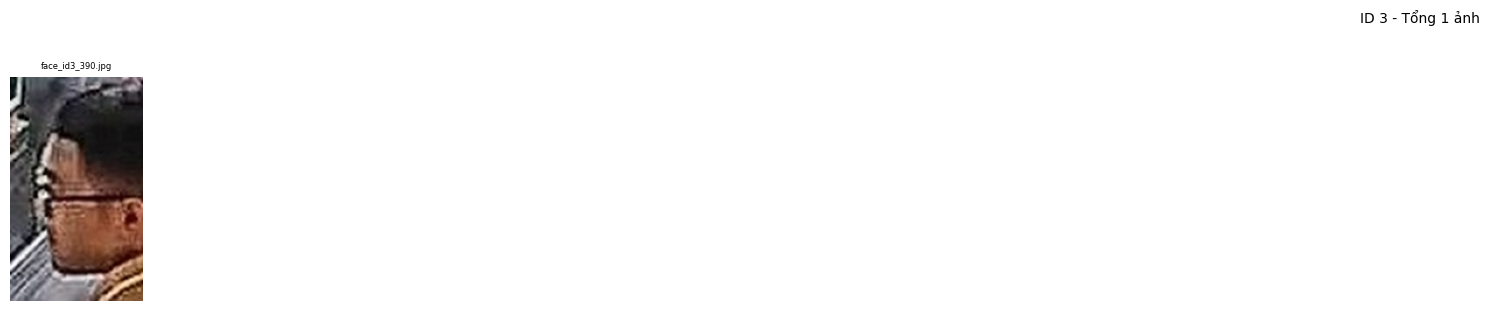

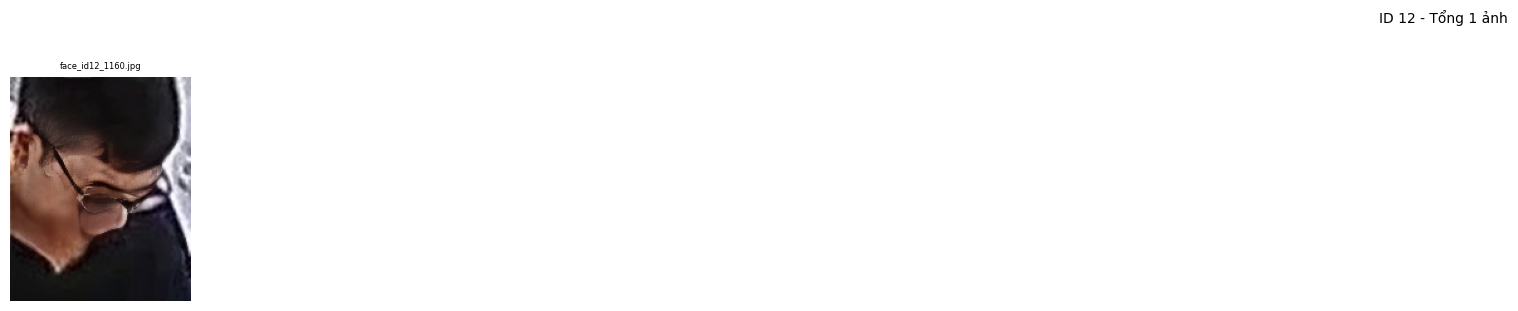

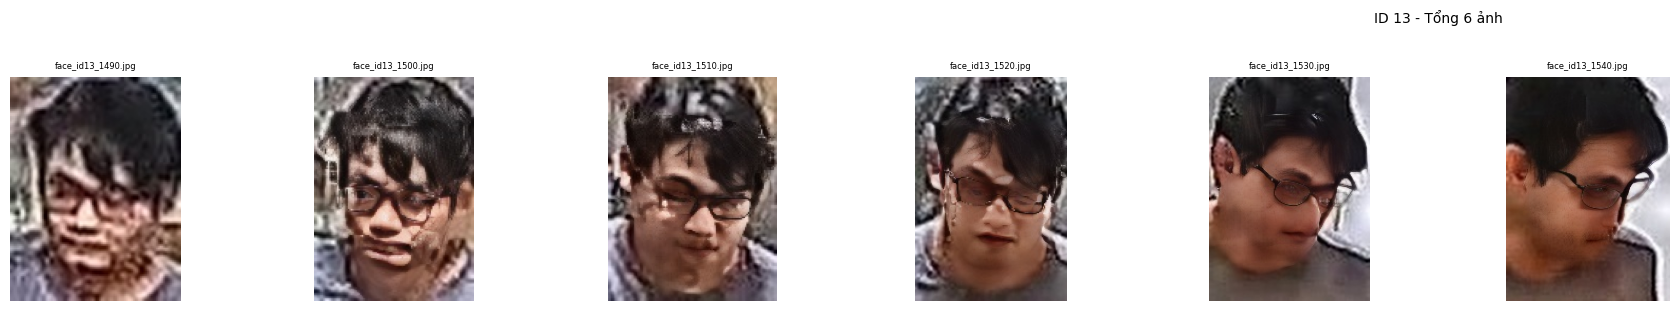

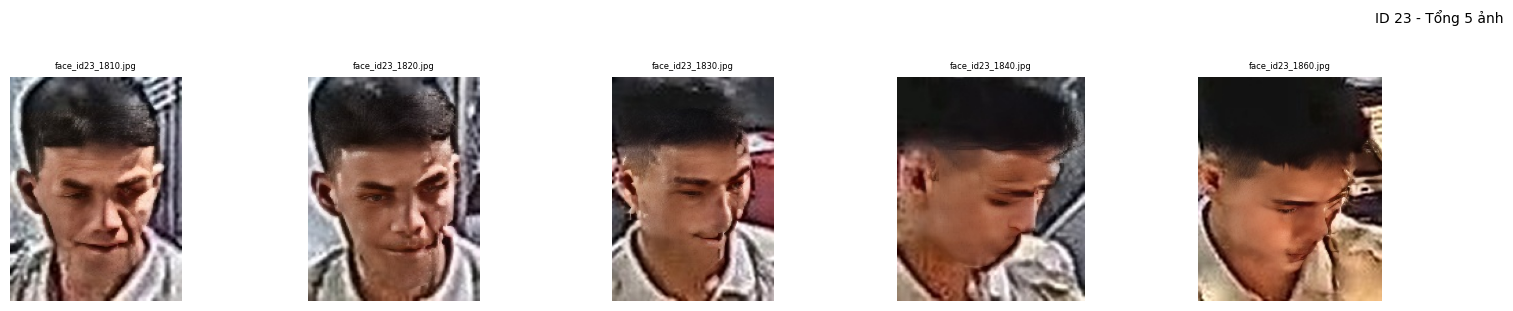

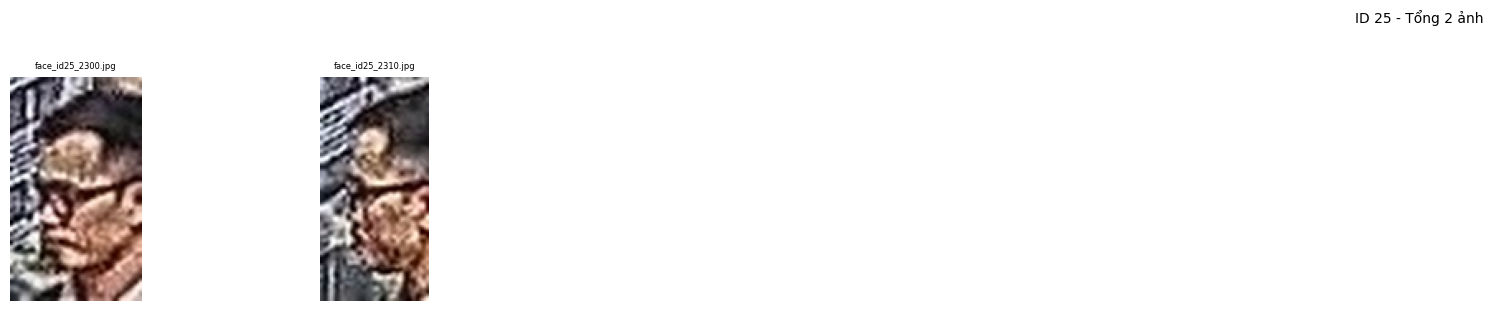

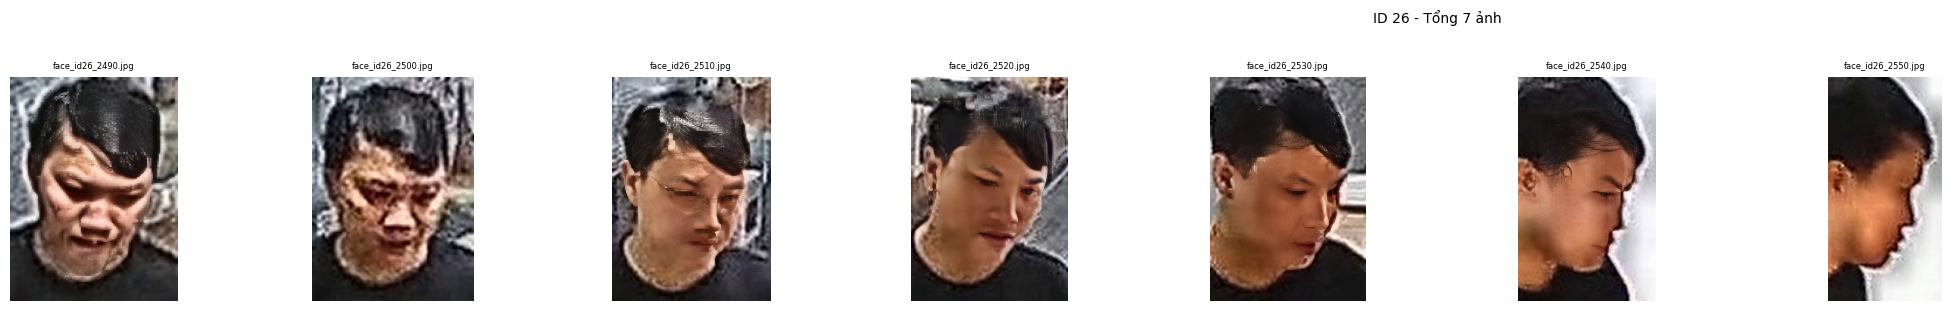

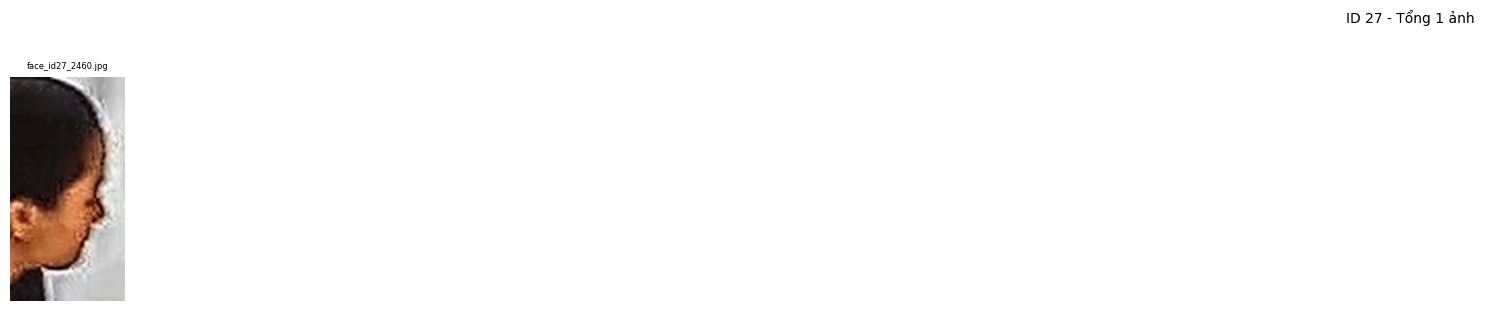

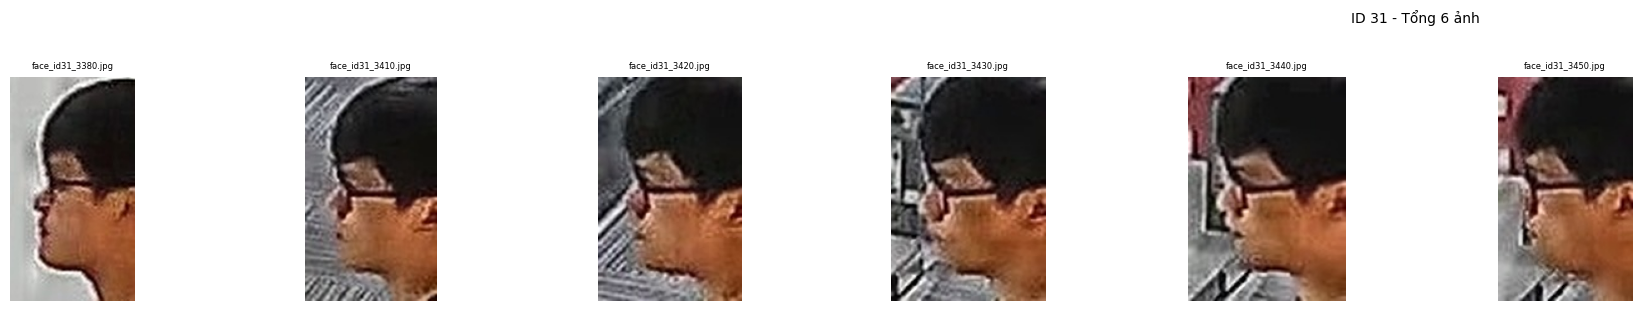

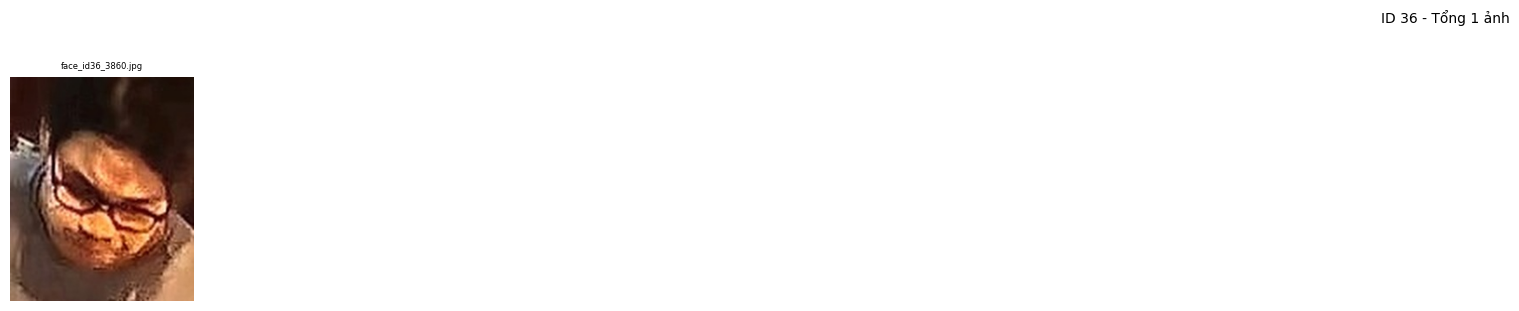

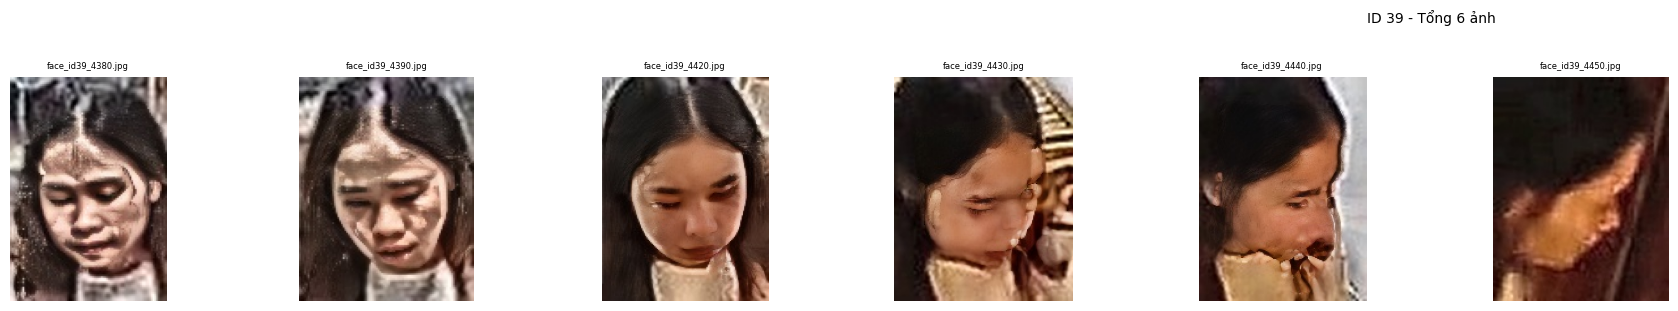

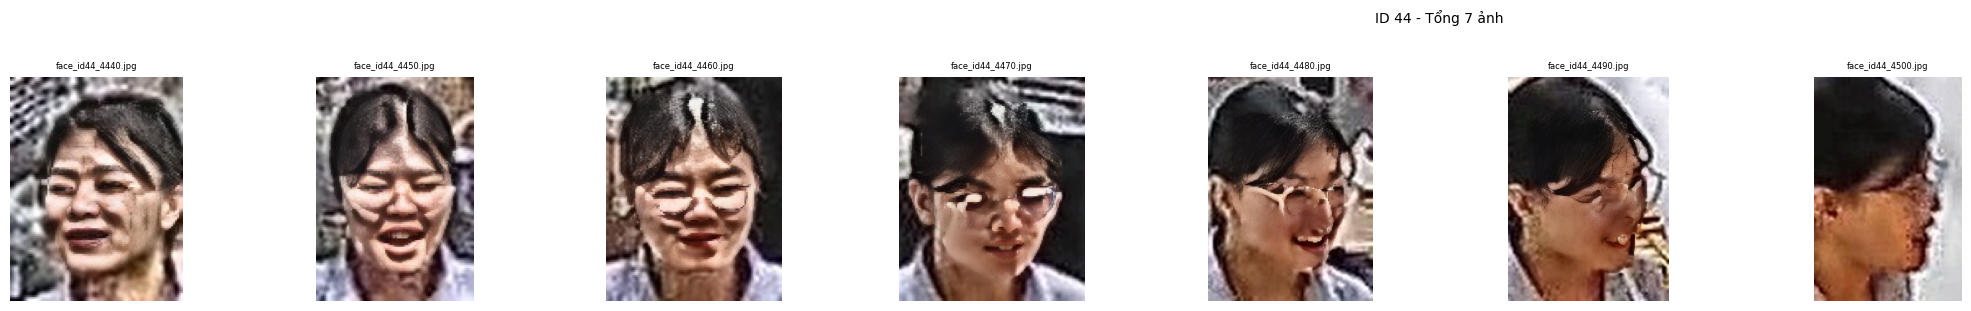

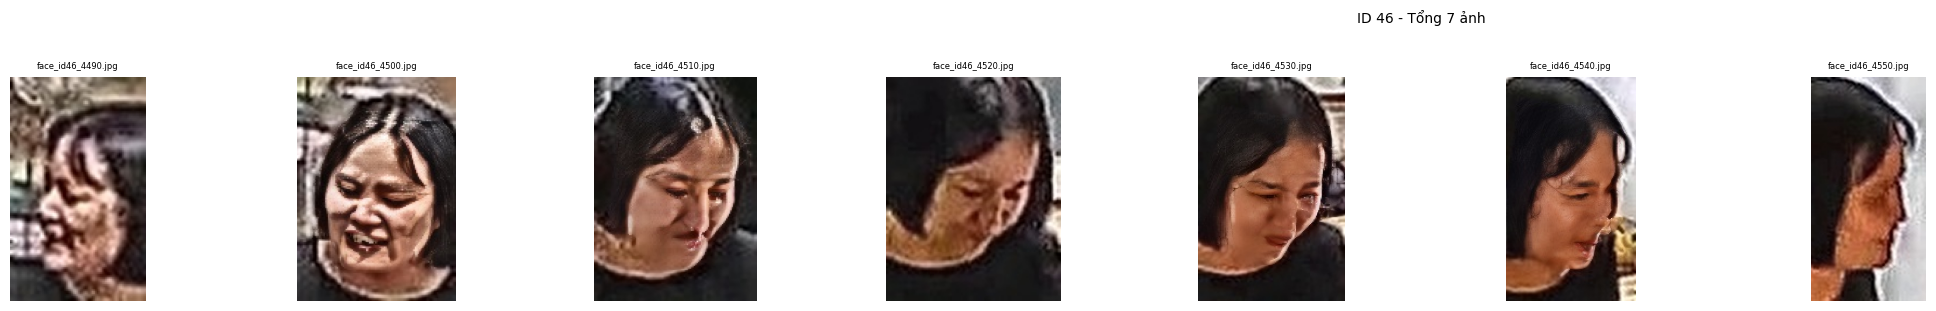

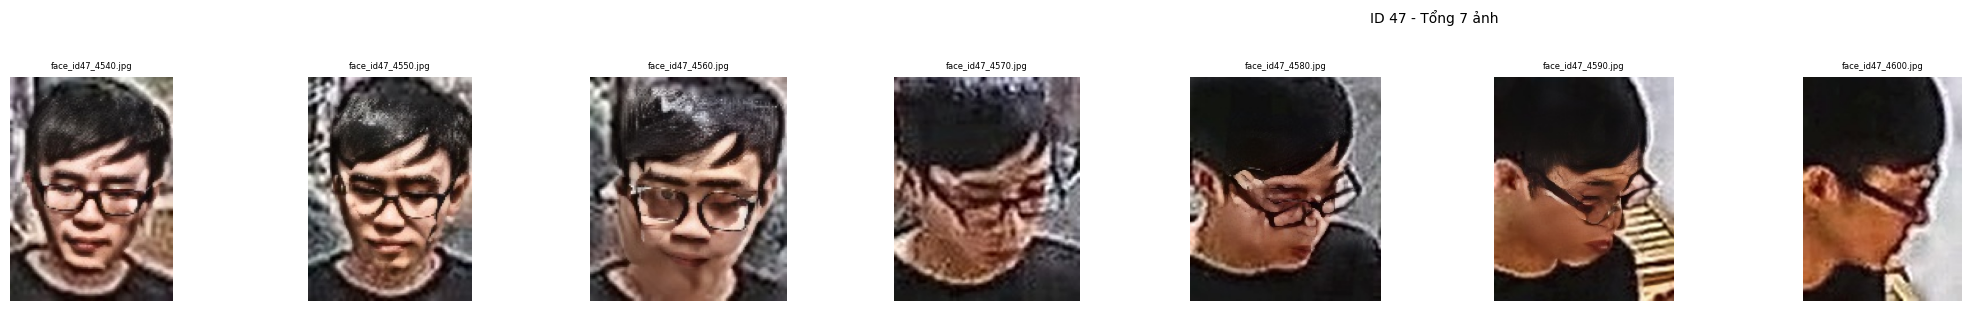

In [11]:
if not groups_roi:
    print("Không tìm thấy ảnh trong thư mục.")
else:
    print(f"Tìm thấy {len(groups_roi)} ID trong thư mục {DIR}")

    for tid, files in sorted(groups_roi.items()):
        n_imgs = len(files)
        n_rows = math.ceil(n_imgs / IMAGES_PER_ROW)
        plt.figure(figsize=(3 * IMAGES_PER_ROW, 3 * n_rows))
        for idx, fname in enumerate(files):
            img = cv2.imread(os.path.join(DIR, fname))
            if img is None:
                continue

            plt.subplot(n_rows, IMAGES_PER_ROW, idx + 1)
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(f"{fname}", fontsize=6)
            plt.axis("off")

        plt.suptitle(f"ID {tid} - Tổng {n_imgs} ảnh", fontsize=10, y=1.02)
        plt.tight_layout()
        plt.show()